# 📊 01. Exploratory Data Analysis


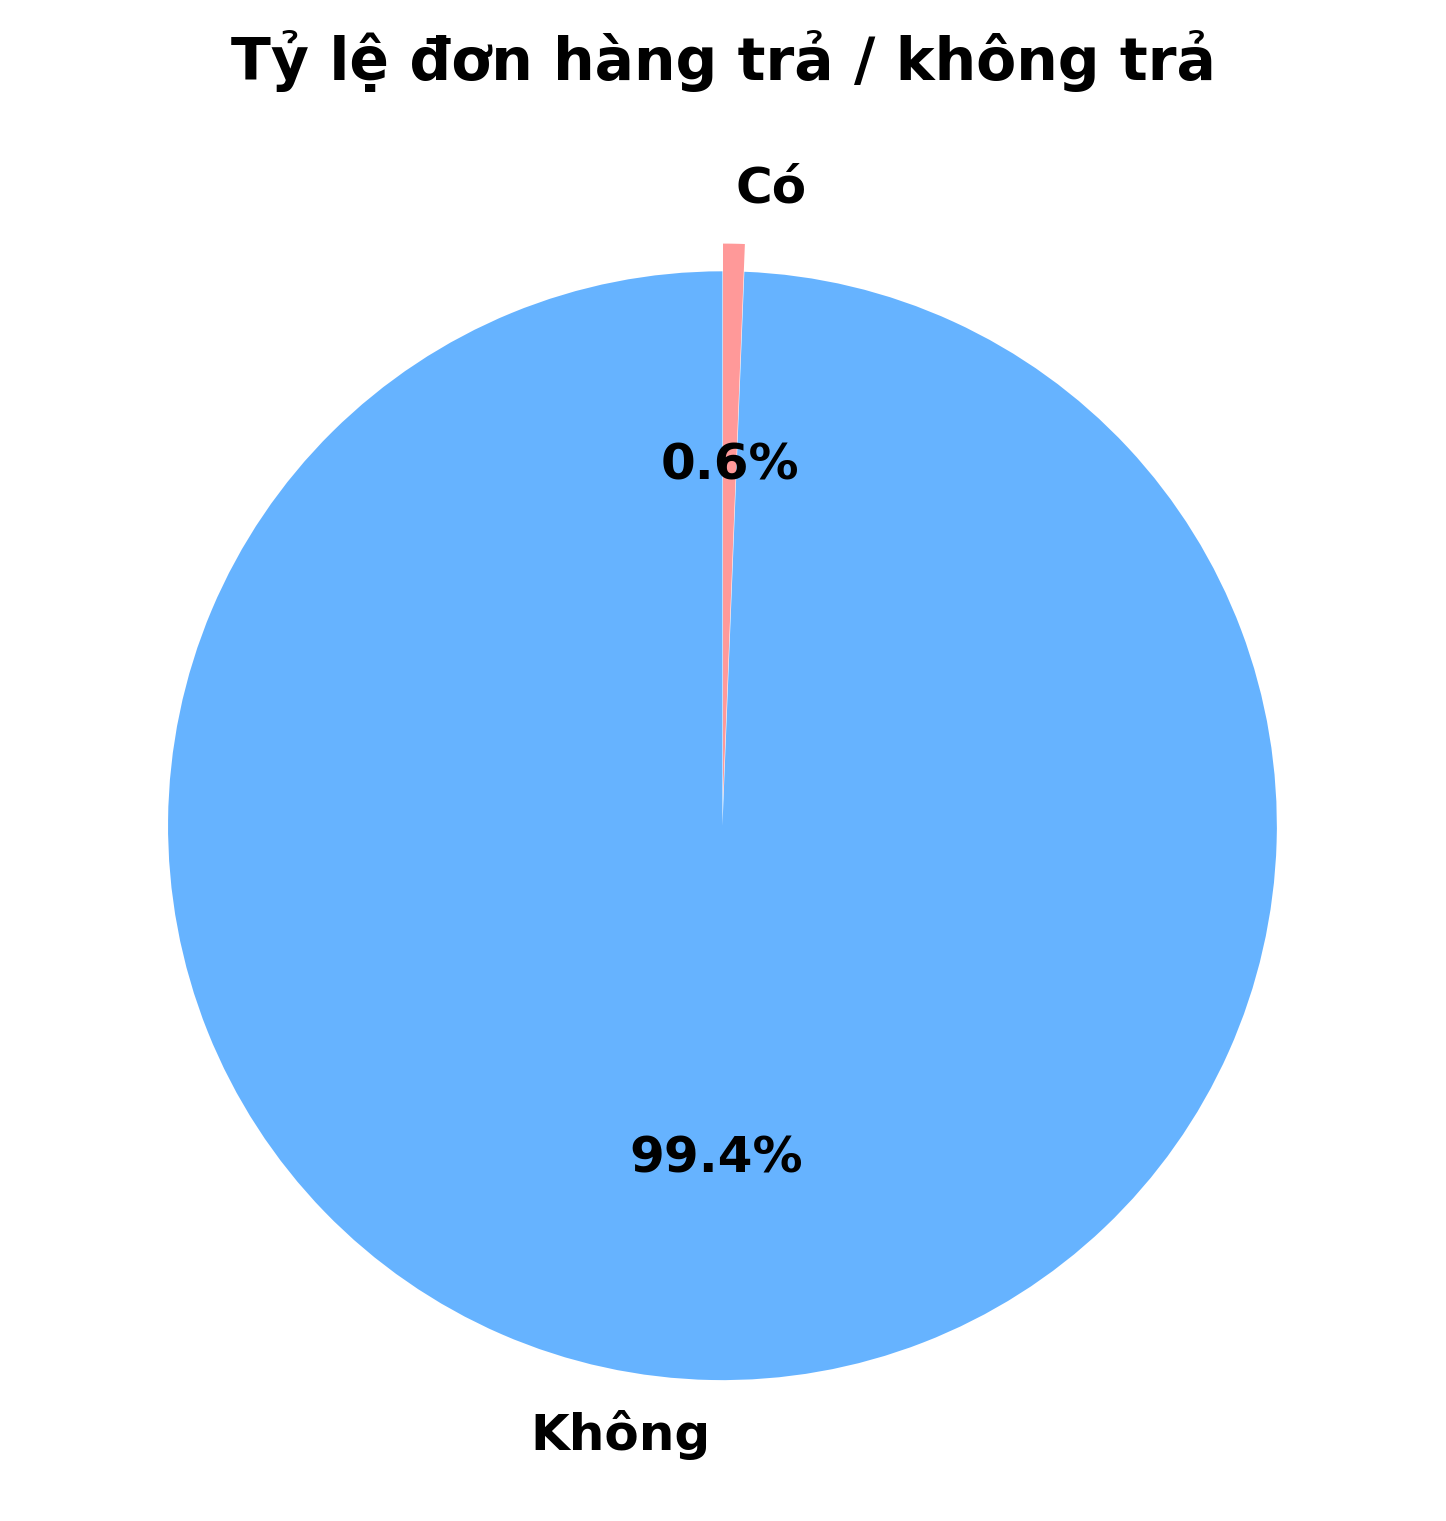

In [1]:
# Biểu đồ 5: Tỷ lệ %
plt.figure(figsize=(6,6))
counts = orders['Trả hàng'].value_counts()
labels = counts.index
colors = ['#66b3ff','#ff9999']
explode = (0.05, 0)
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, explode=explode, textprops={'fontsize': 12, 'fontweight': 'bold'})
plt.title('Tỷ lệ đơn hàng trả / không trả', fontsize=14, fontweight='bold')
plt.savefig('return_ratio_pie.png', bbox_inches='tight', dpi=300)
plt.show()

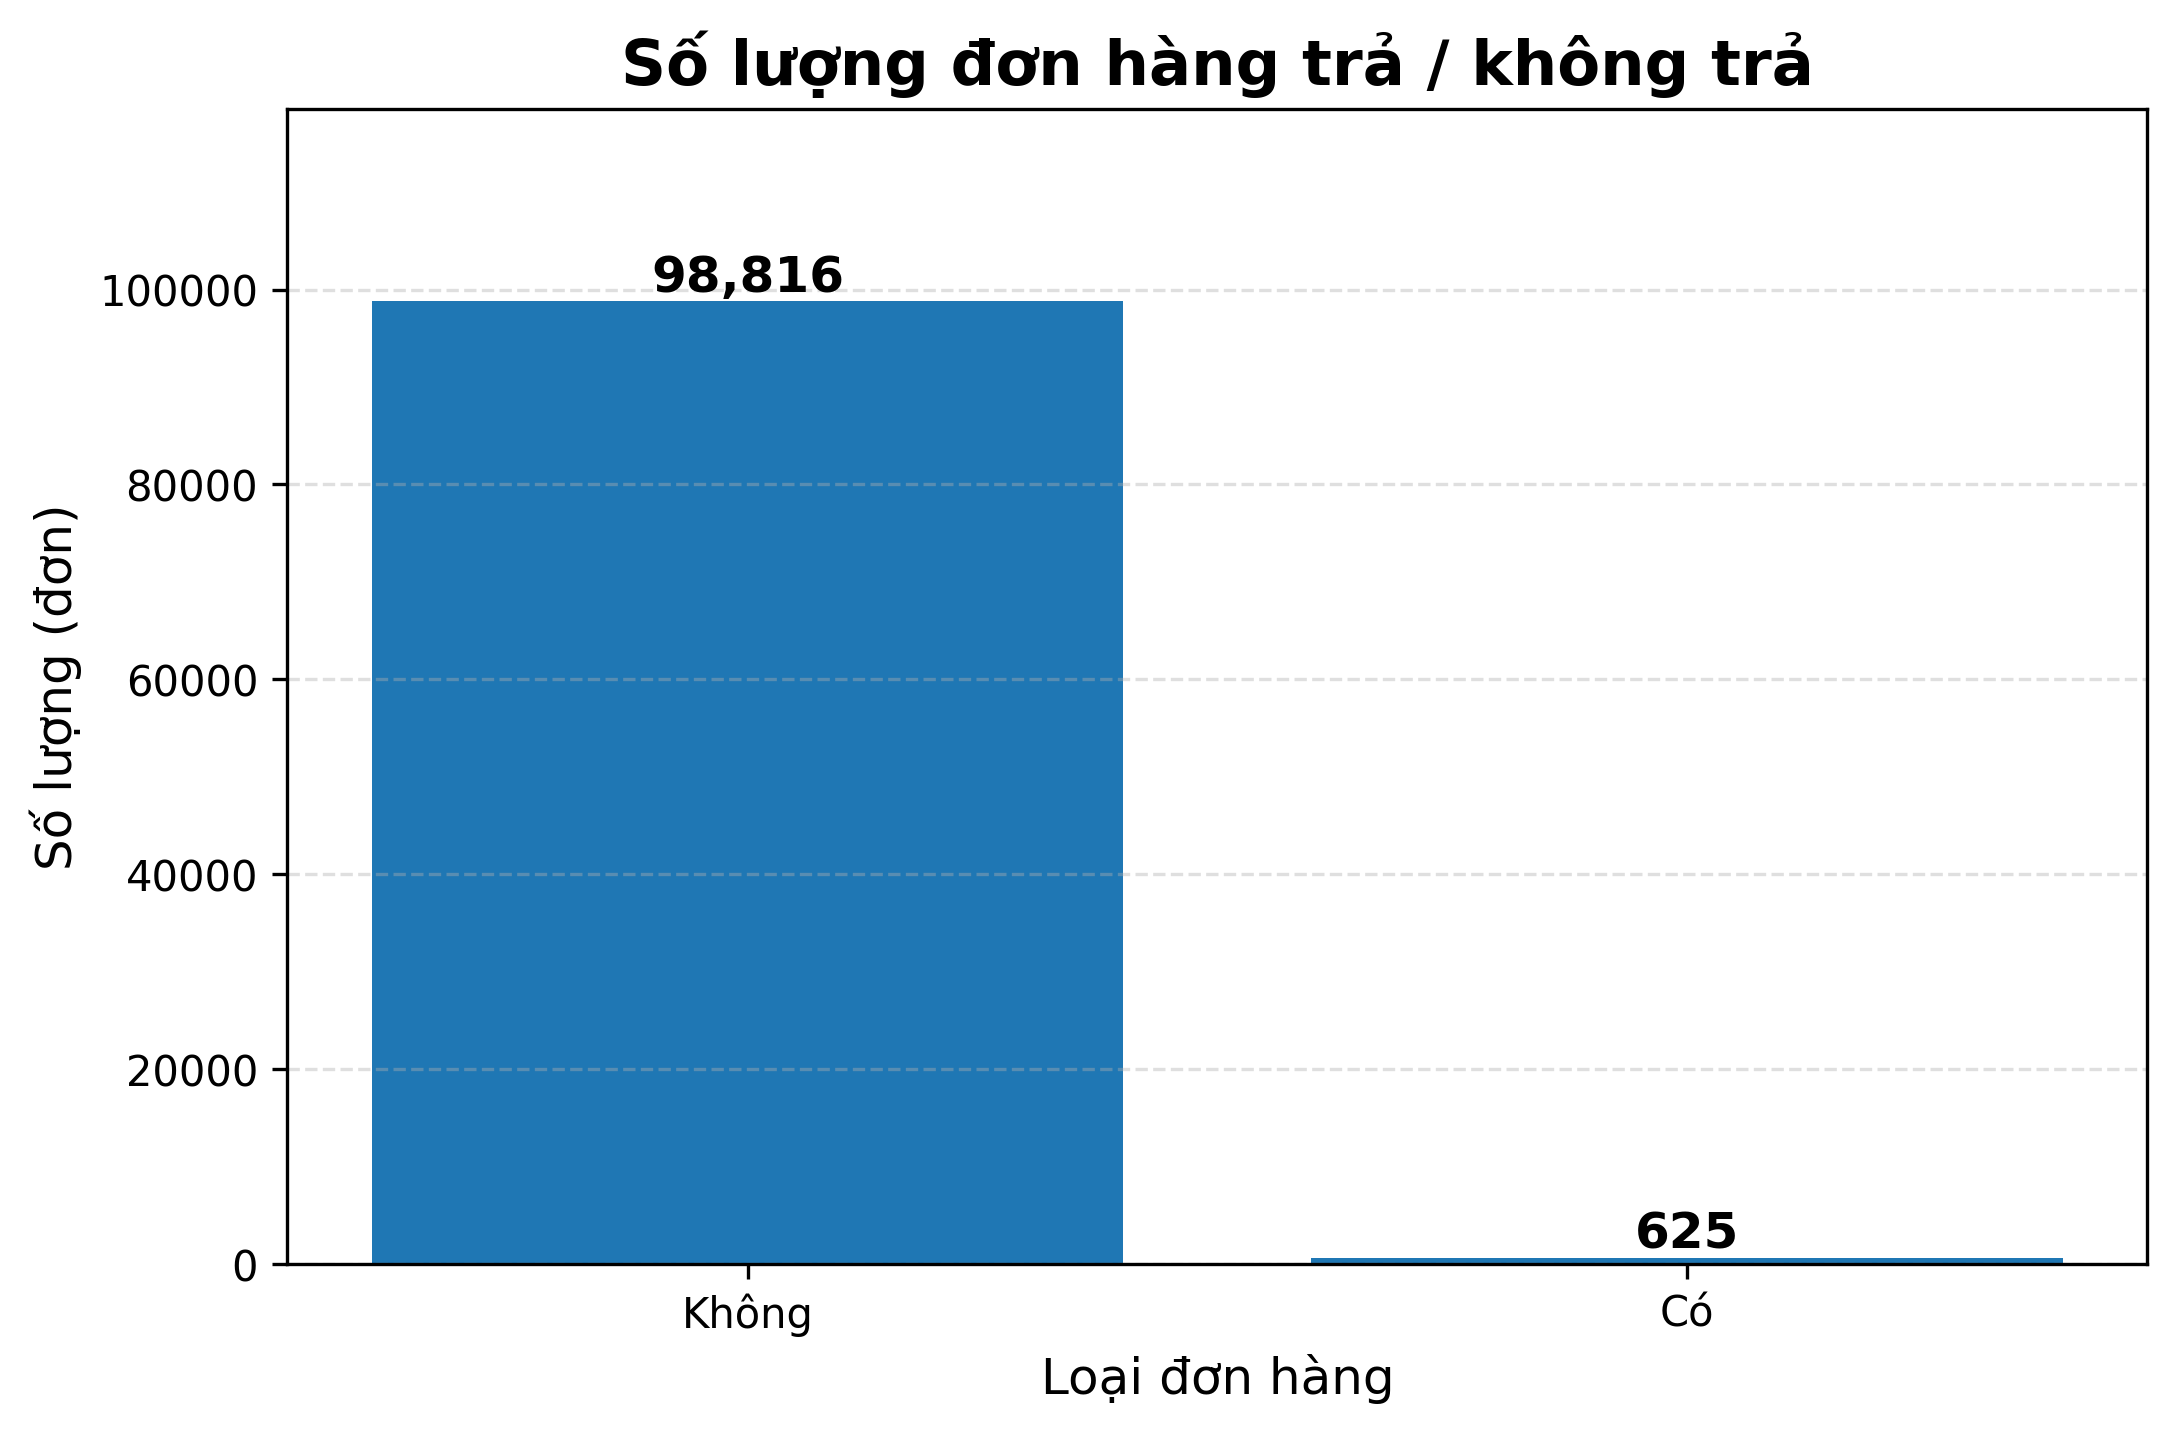

In [1]:
# Biểu đồ 1: Số lượng đơn
plt.figure(figsize=(8,5))
counts = orders['Trả hàng'].value_counts()
bars = plt.bar(counts.index, counts)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{int(yval):,}', ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.title('Số lượng đơn hàng trả / không trả', fontsize=15, fontweight='bold')
plt.savefig('order_status_chart.png', bbox_inches='tight', dpi=300)
plt.show()

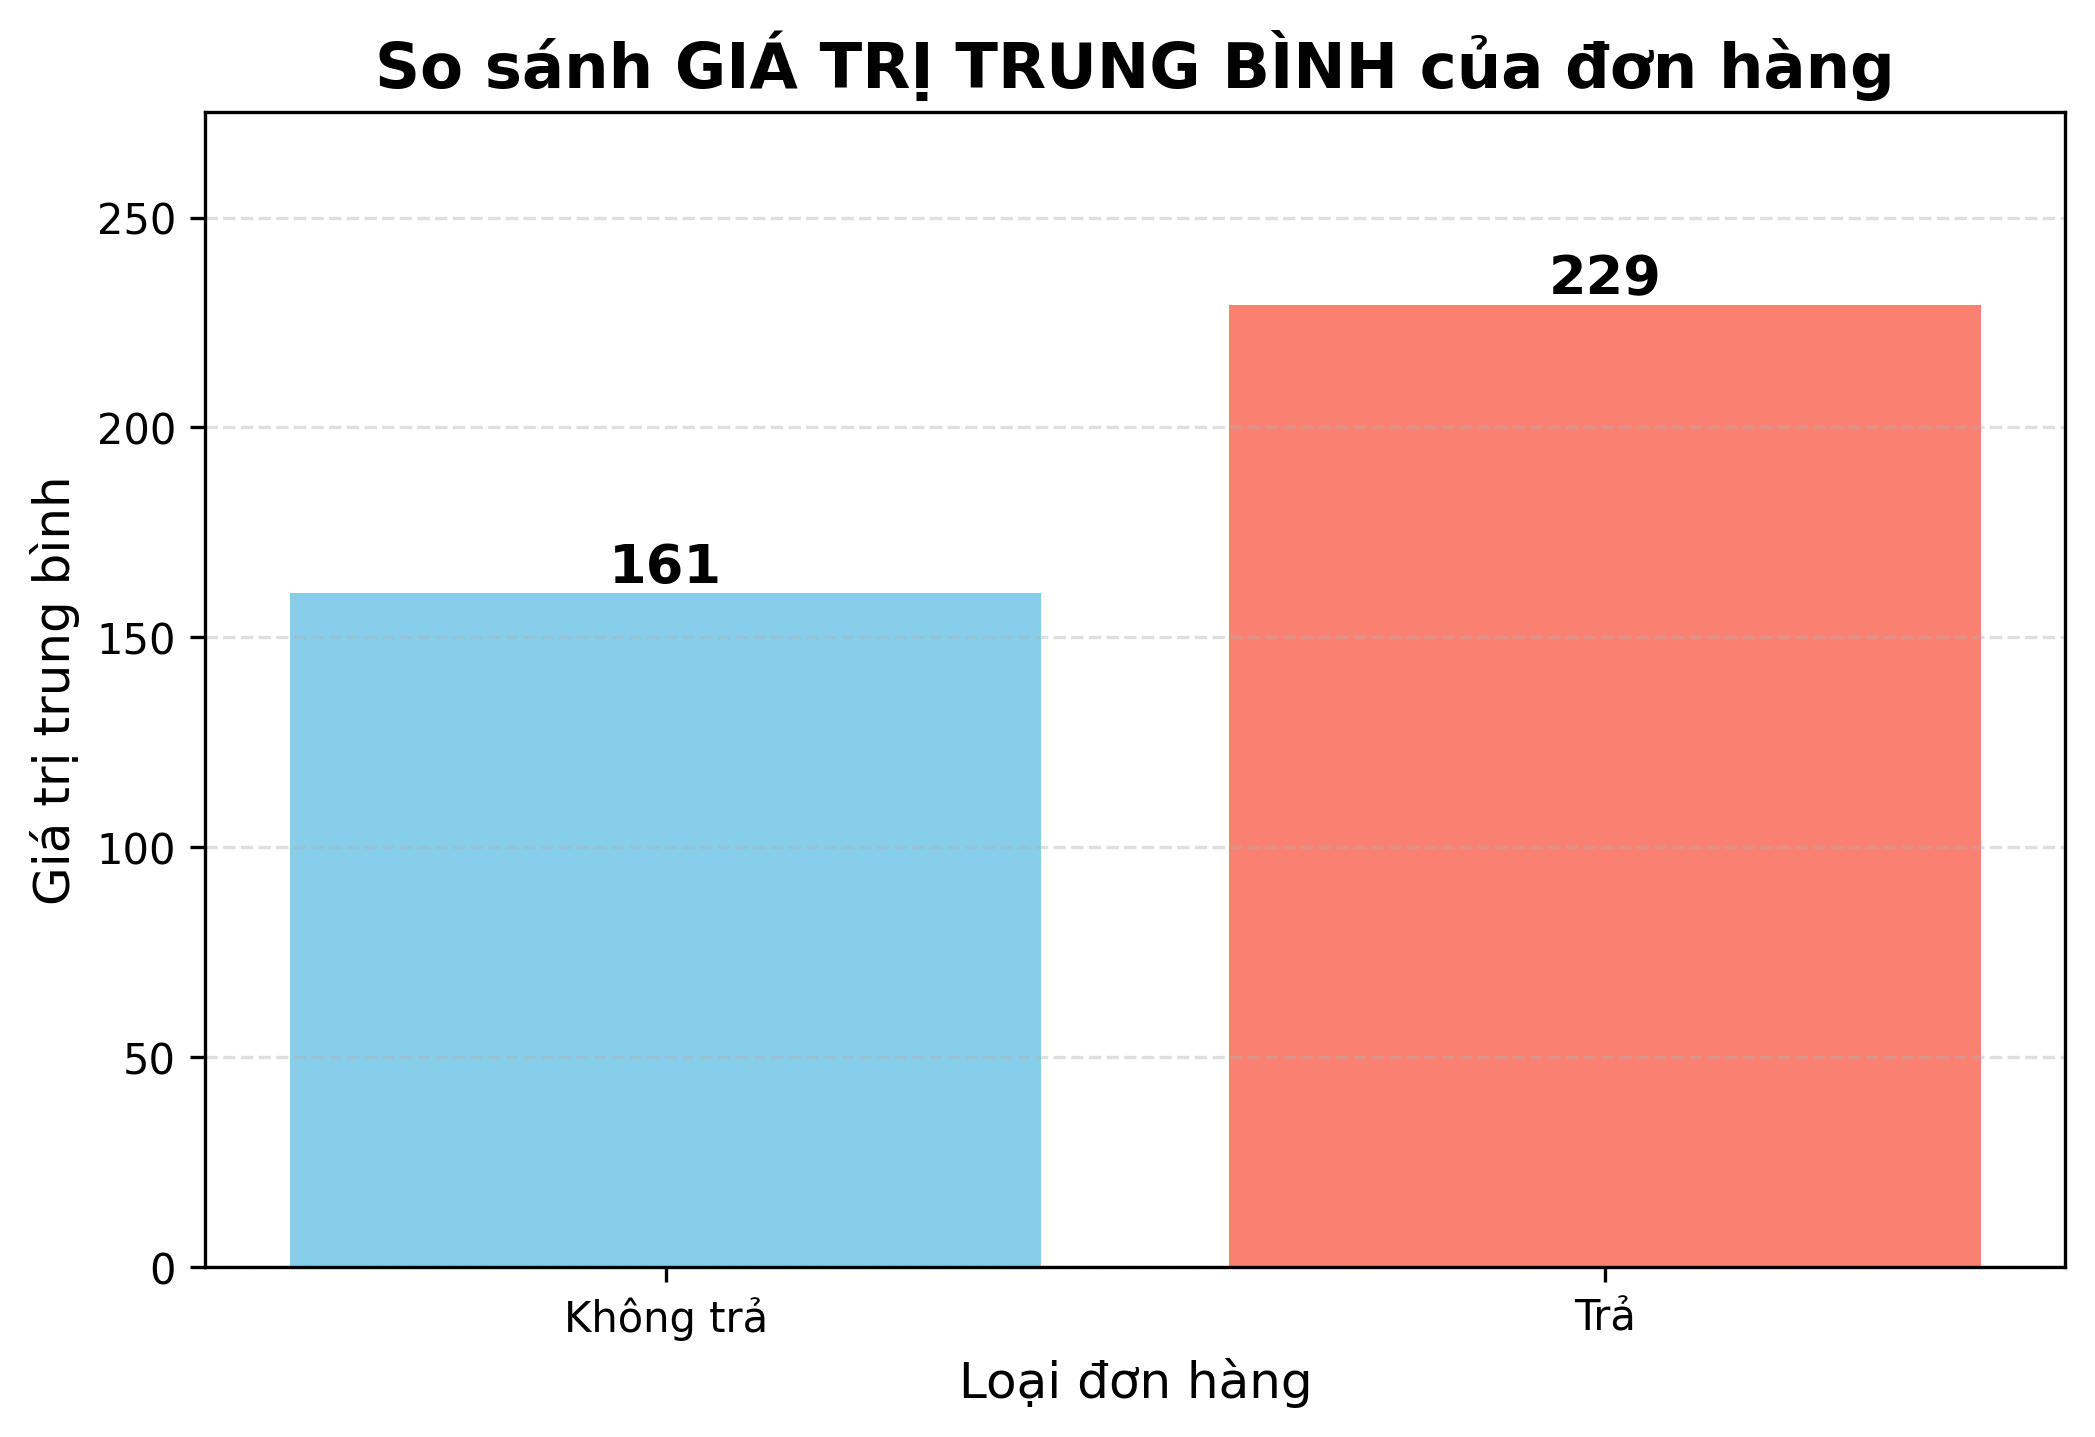

In [1]:
# Biểu đồ 4: So sánh giá trị TB
plt.figure(figsize=(8,5))
avg_no = df[df['is_return']==0]['payment_value'].mean()
avg_yes = df[df['is_return']==1]['payment_value'].mean()
bars = plt.bar(['Không trả', 'Trả'], [avg_no, avg_yes], color=['skyblue', 'salmon'])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:,.0f}', ha='center', va='bottom', fontsize=13, fontweight='bold')
plt.title('So sánh GIÁ TRỊ TRUNG BÌNH của đơn hàng', fontsize=15, fontweight='bold')
plt.savefig('avg_payment_comparison.png', bbox_inches='tight', dpi=300)
plt.show()

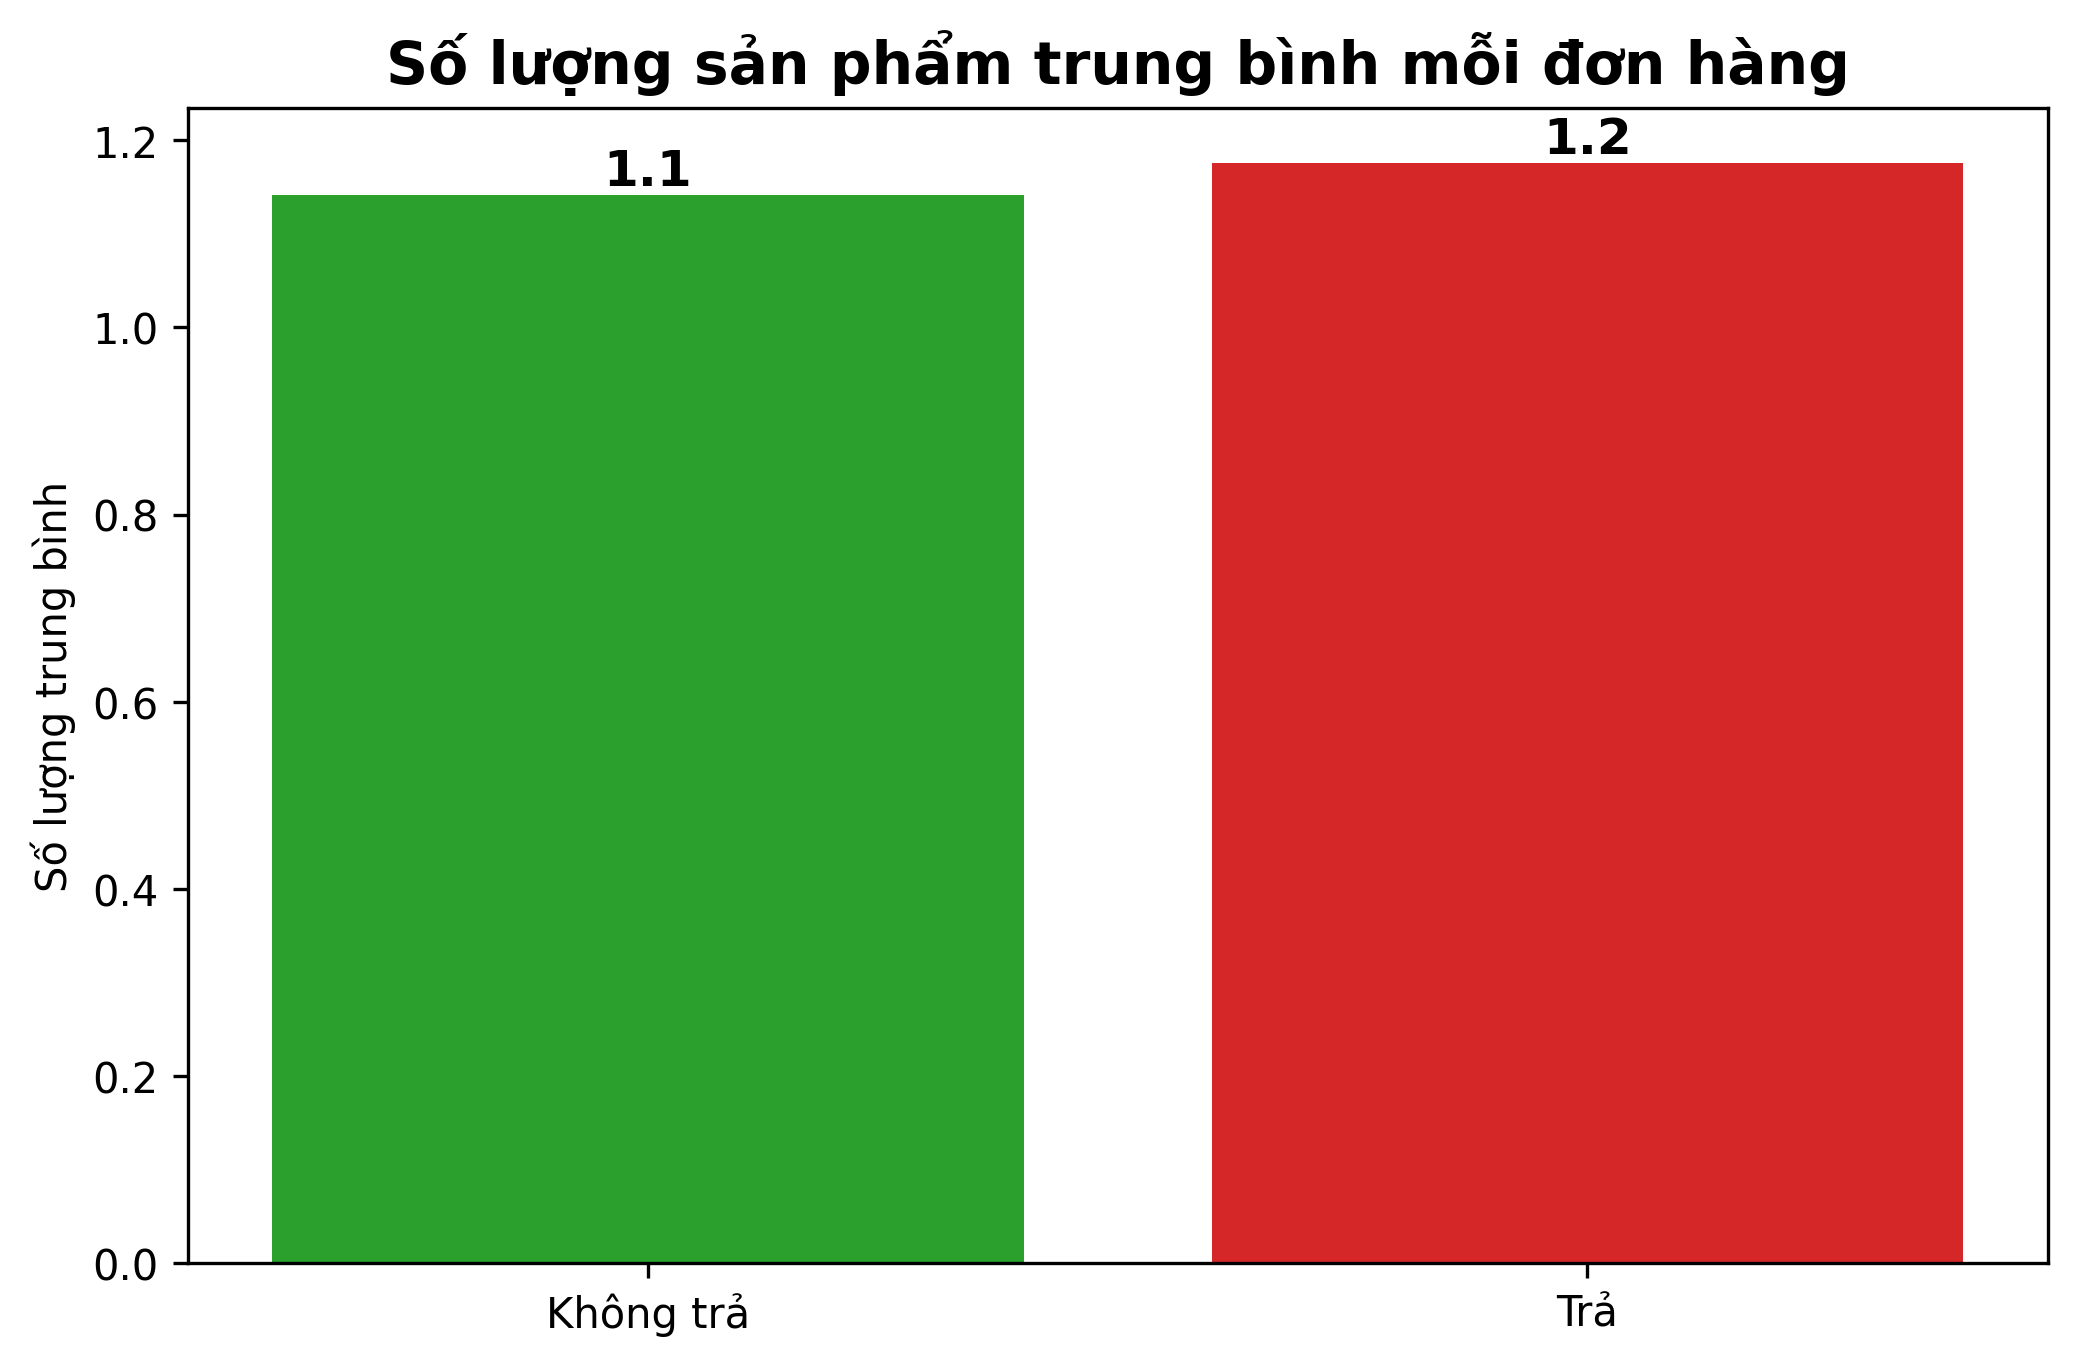

In [1]:
# Biểu đồ 6: Số lượng SP TB
avg_items_no = df[df['is_return'] == 0]['item_count'].mean()
avg_items_yes = df[df['is_return'] == 1]['item_count'].mean()
plt.figure(figsize=(8,5))
bars = plt.bar(['Không trả', 'Trả'], [avg_items_no, avg_items_yes], color=['#2ca02c', '#d62728'])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.1f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.title('Số lượng sản phẩm trung bình mỗi đơn hàng', fontweight='bold', fontsize=14)
plt.savefig('avg_items_comparison.png', bbox_inches='tight', dpi=300)
plt.show()

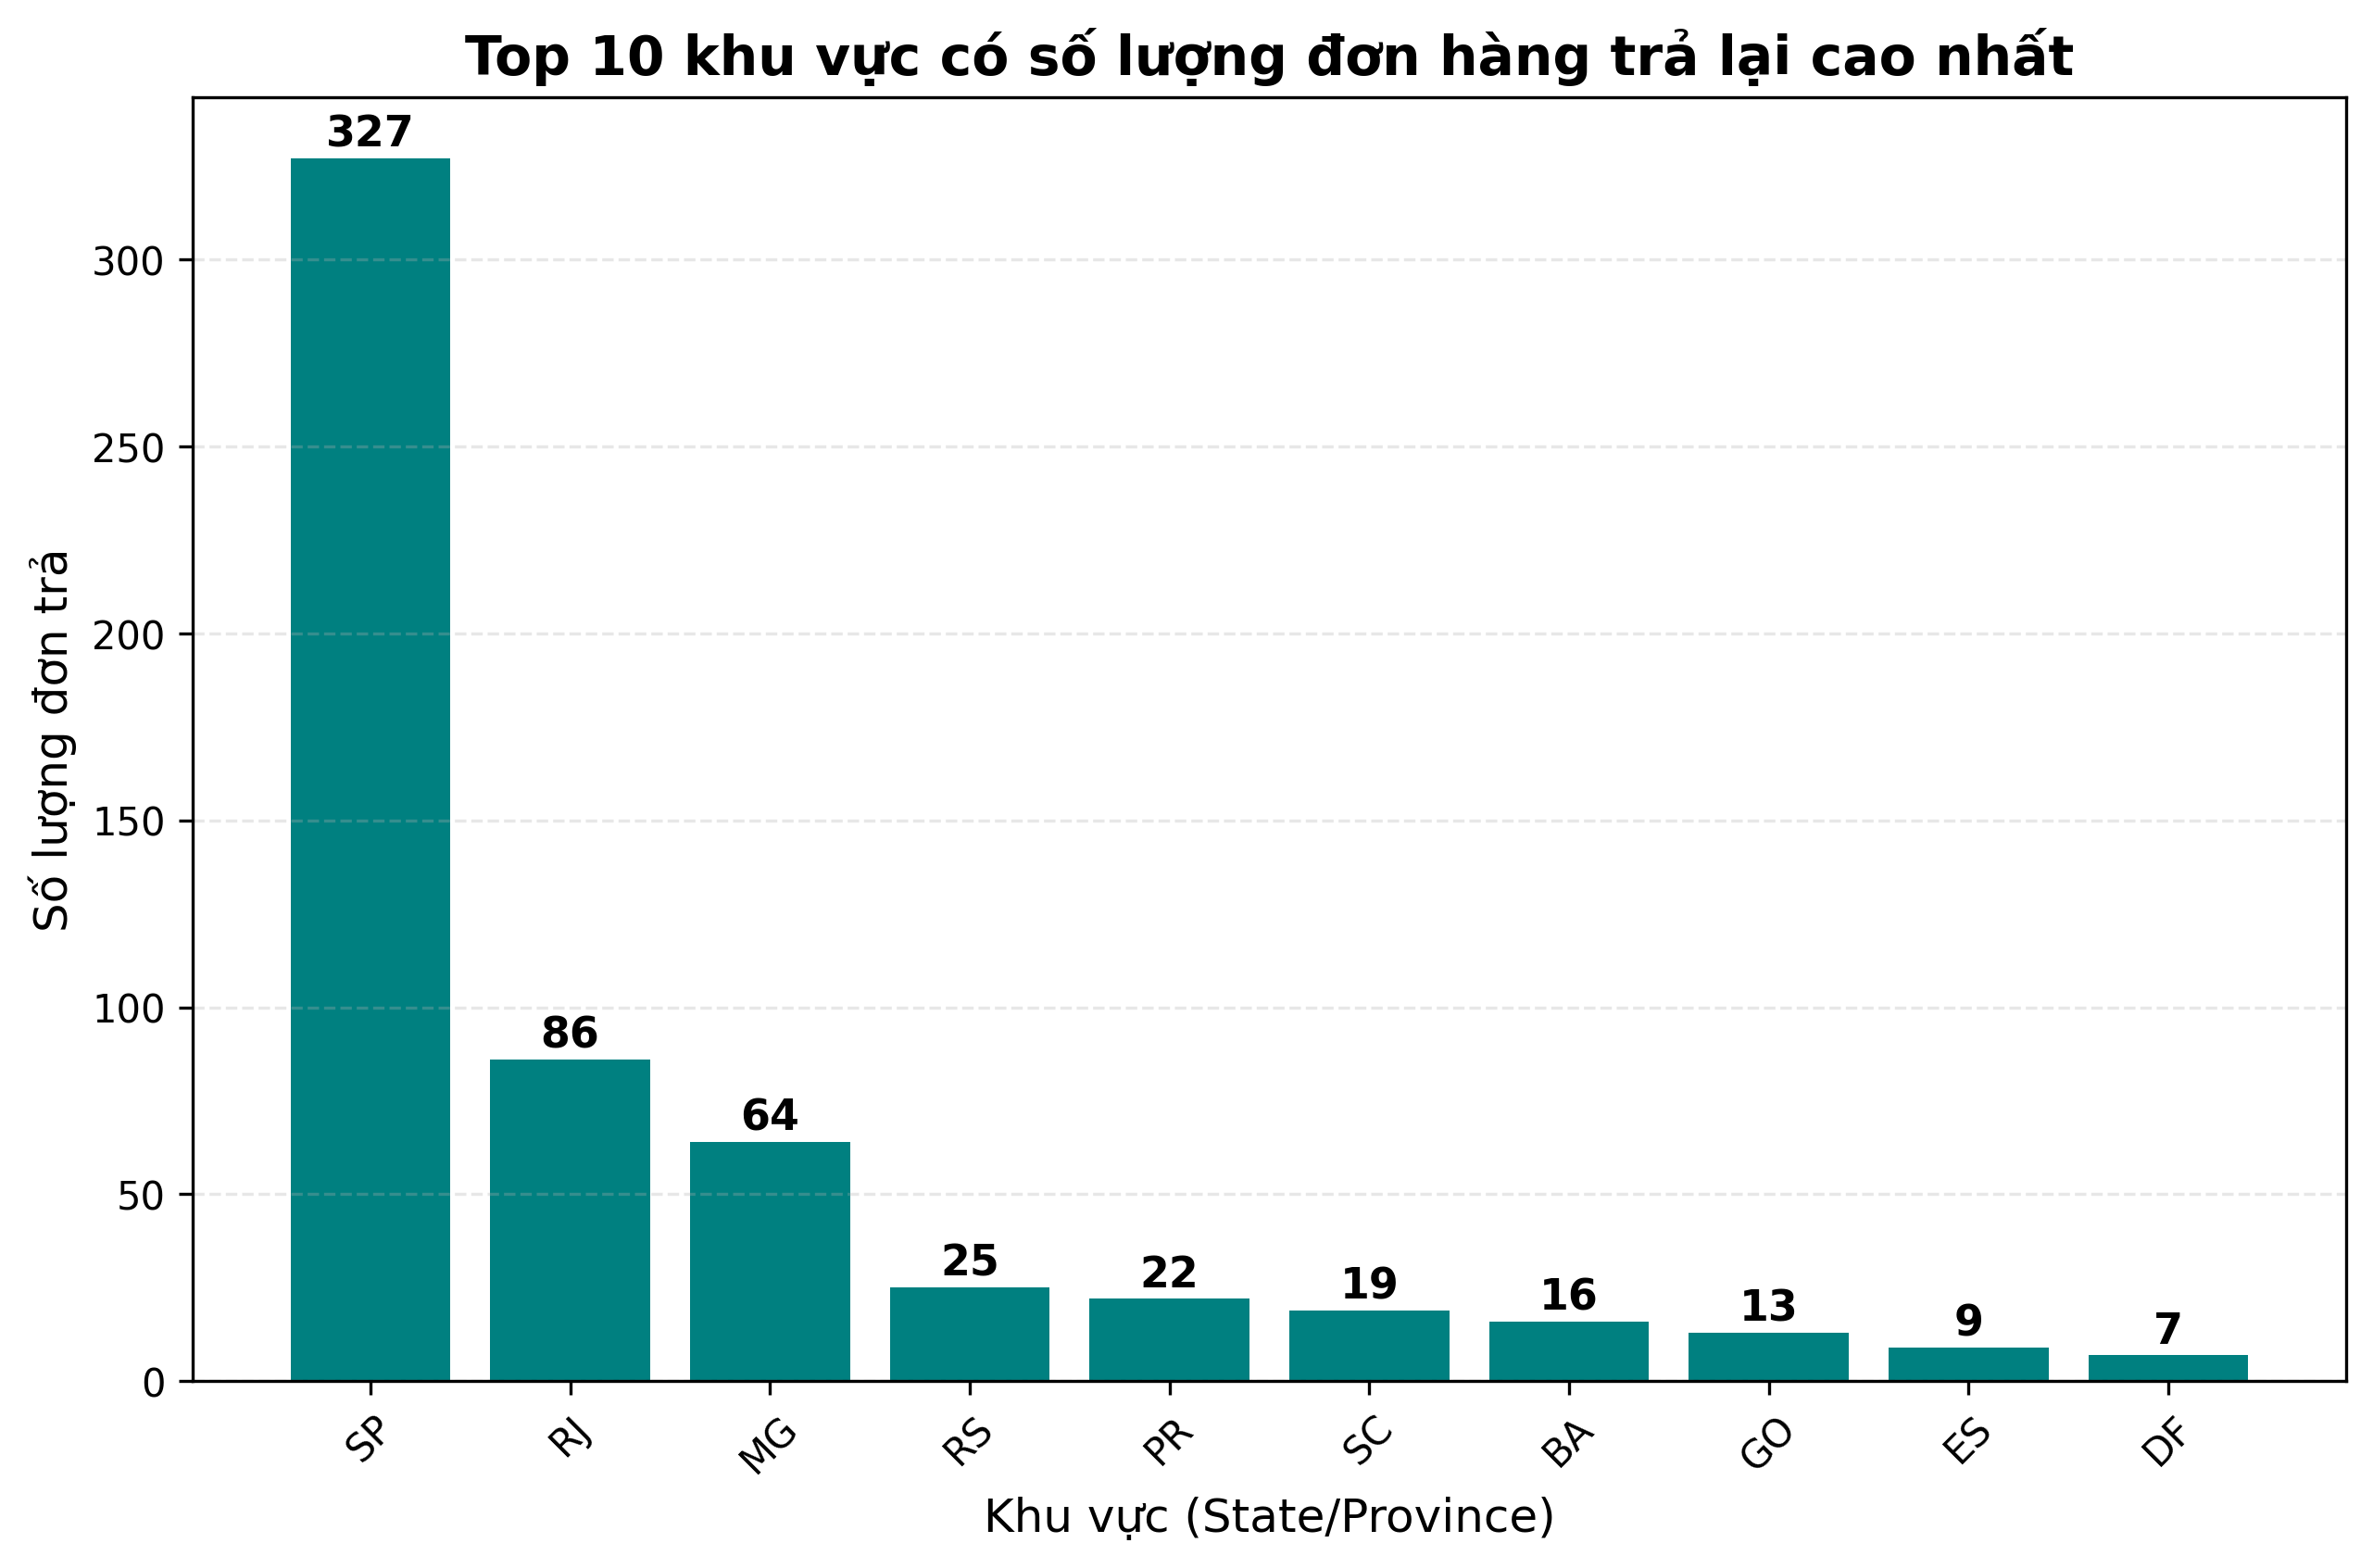

In [1]:
# Biểu đồ 7: Top 10 khu vực
top_states = df[df['is_return']==1]['customer_state'].value_counts().head(10)
plt.figure(figsize=(10,6))
bars = plt.bar(top_states.index, top_states.values, color='teal')
plt.title('Top 10 khu vực có số lượng đơn hàng trả lại cao nhất', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.savefig('top_return_states.png', bbox_inches='tight', dpi=300)
plt.show()

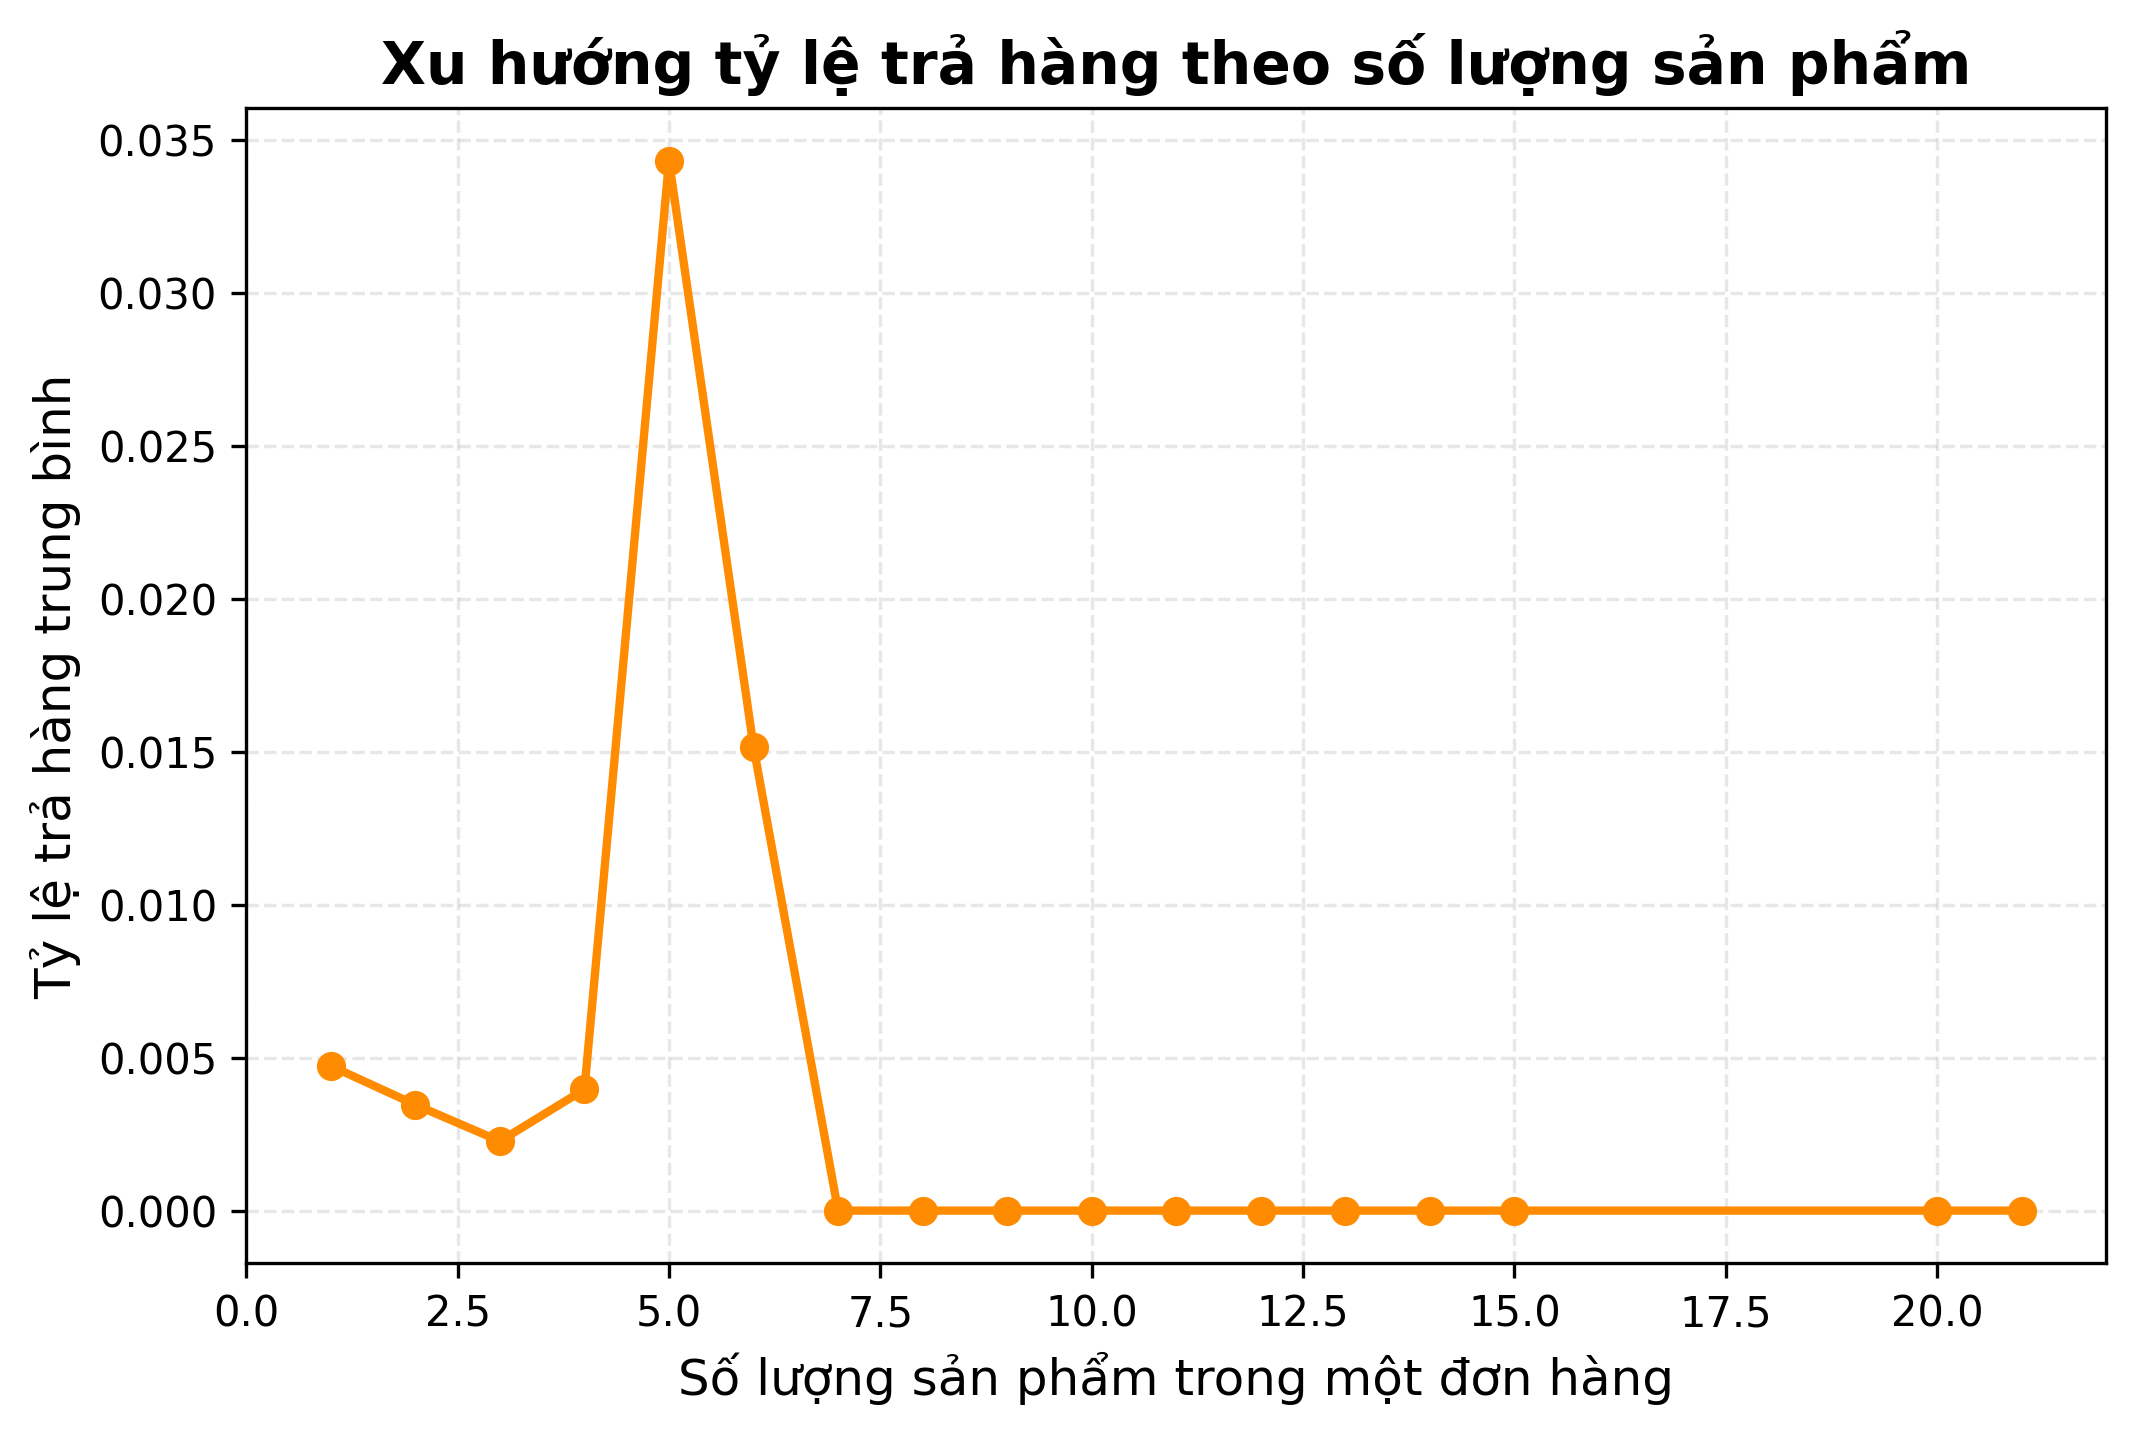

In [1]:
# Biểu đồ 8: Xu hướng
group = df.groupby('item_count')['is_return'].mean()
plt.figure(figsize=(8,5))
plt.plot(group.index, group.values, marker='o', color='darkorange', linewidth=2)
plt.title('Xu hướng tỷ lệ trả hàng theo số lượng sản phẩm', fontweight='bold', fontsize=14)
plt.savefig('return_rate_trend.png', bbox_inches='tight', dpi=300)
plt.show()

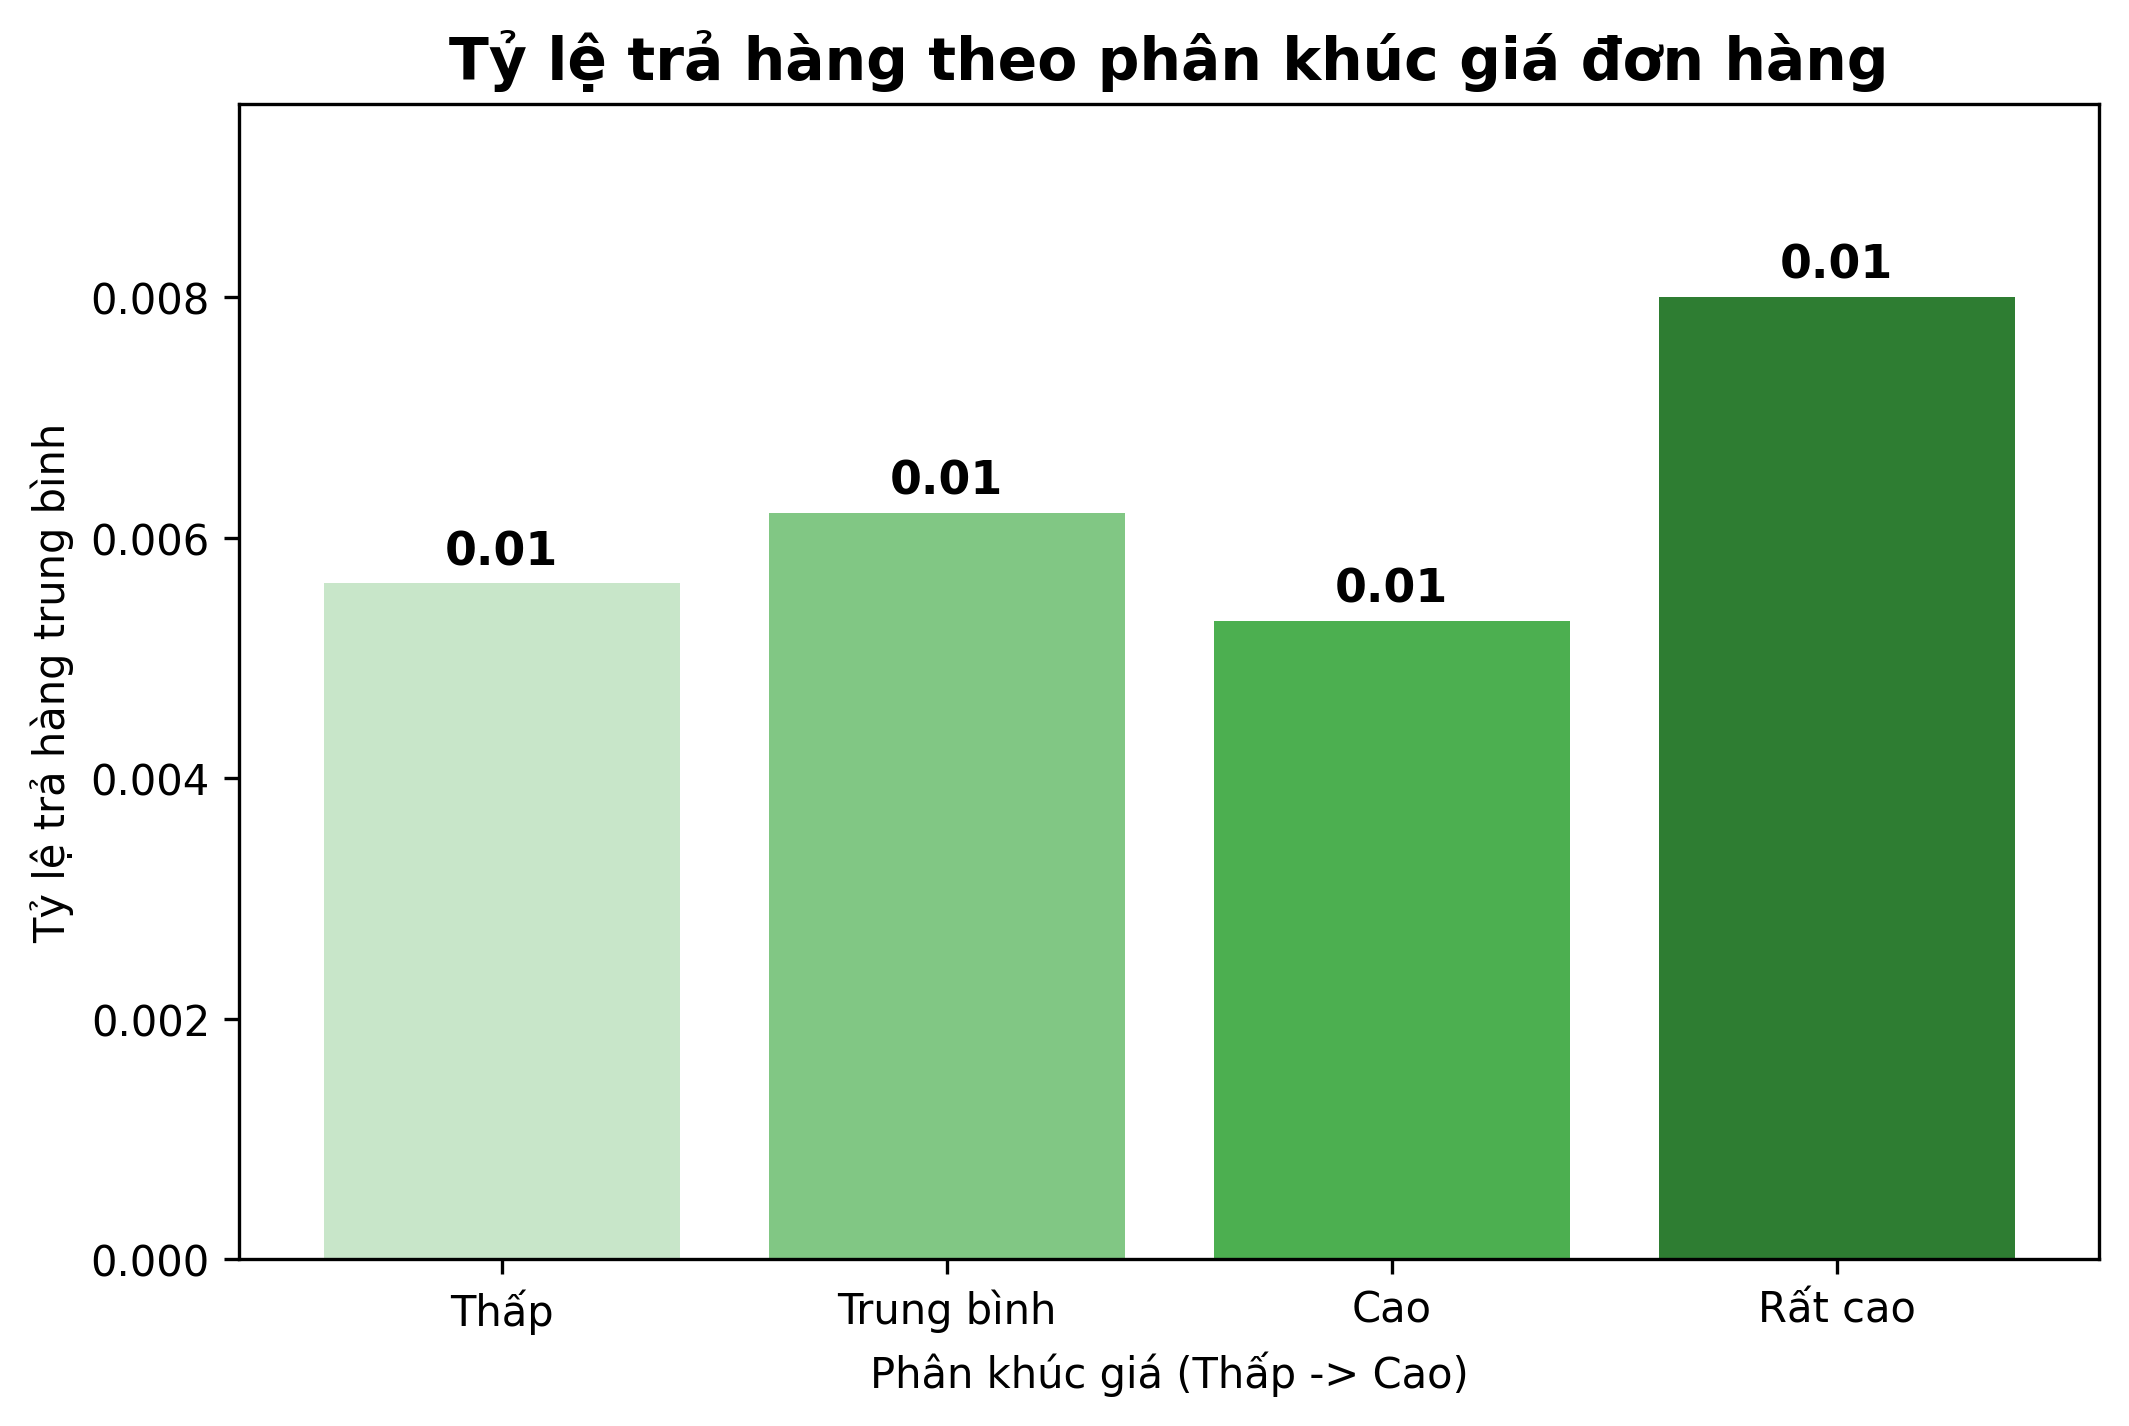

In [1]:
# Biểu đồ 9: Phân khúc giá
df['price_group'] = pd.qcut(df['payment_value'], 4, labels=['Thấp', 'Trung bình', 'Cao', 'Rất cao'])
group = df.groupby('price_group')['is_return'].mean()
plt.figure(figsize=(8,5))
plt.bar(group.index.astype(str), group.values, color=['#c8e6c9', '#81c784', '#4caf50', '#2e7d32'])
plt.title('Tỷ lệ trả hàng theo phân khúc giá đơn hàng', fontweight='bold', fontsize=14)
plt.savefig('return_rate_by_price_group.png', bbox_inches='tight', dpi=300)
plt.show()

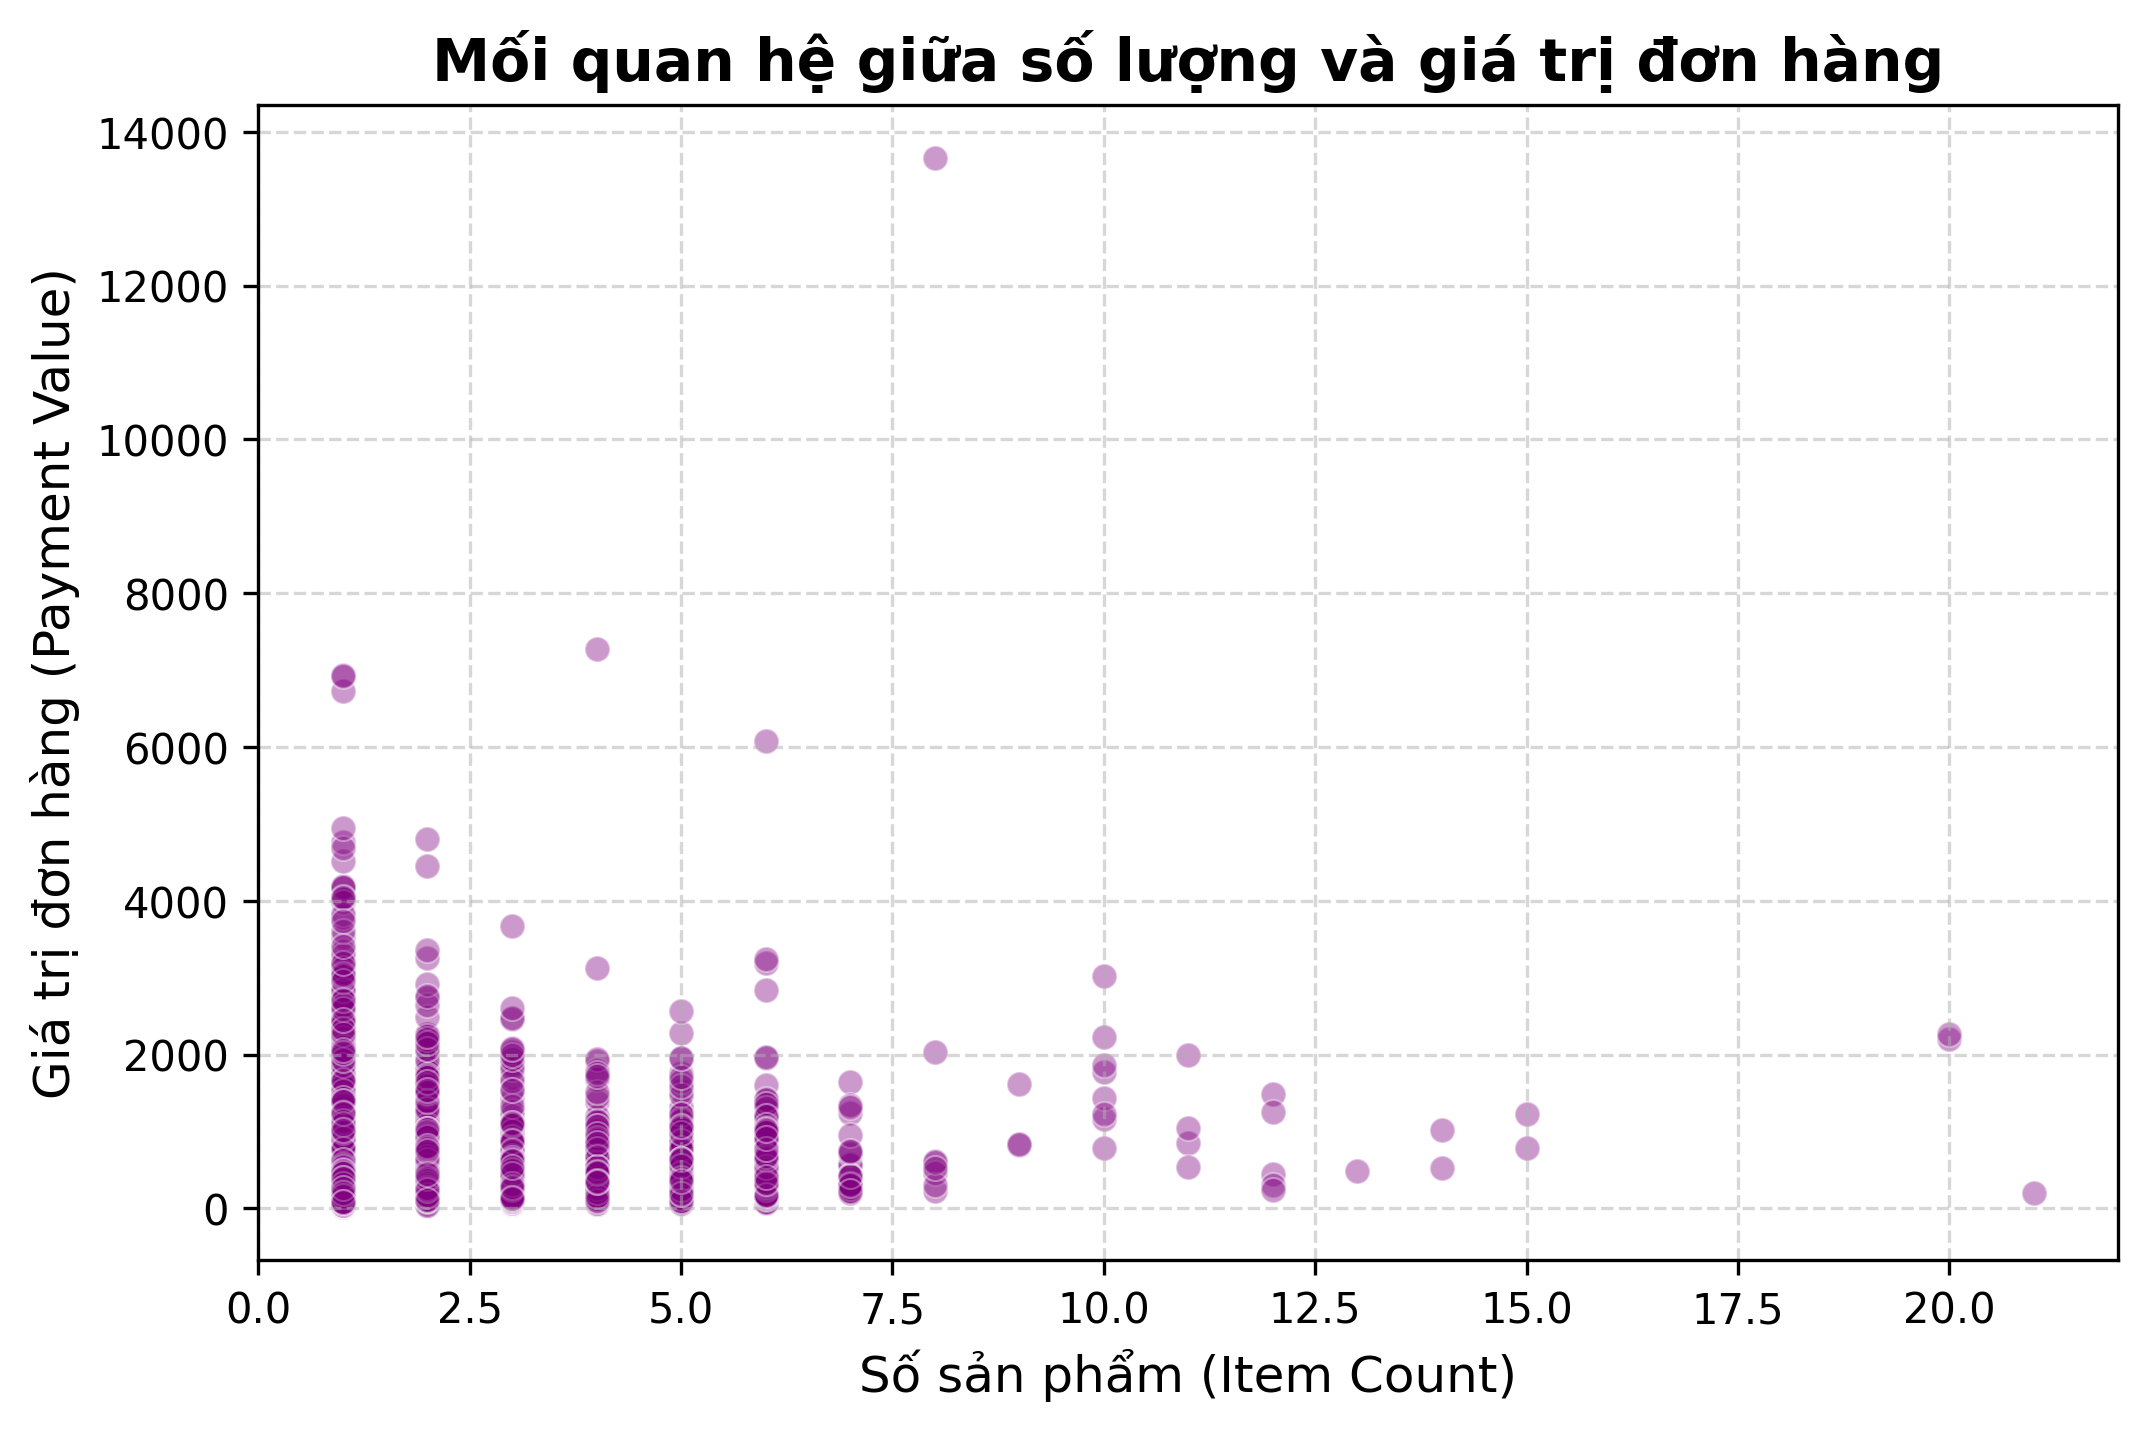

In [1]:
# Biểu đồ 10: Phân tán Scatter
plt.figure(figsize=(8,5))
plt.scatter(df['item_count'], df['payment_value'], alpha=0.4, c='purple')
plt.title('Mối quan hệ giữa số lượng và giá trị đơn hàng', fontweight='bold', fontsize=14)
plt.savefig('item_vs_payment_scatter.png', bbox_inches='tight', dpi=300)
plt.show()